## Imports

In [84]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPatch
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import (
    dtw, 
    format_stats, 
    mean_center, 
    rankbiserialr,
    show_source
)

## Functions

In [2]:
show_source(dtw)

In [3]:
show_source(format_stats)

In [4]:
show_source(mean_center)

In [5]:
show_source(rankbiserialr)

## Load data

In [6]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

N_BOOTS_CI = 10_000

In [7]:
ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

## Is delayed recall more similar to own immediate recall than to the episode?

In [8]:
warp_dists_del_imm = []
warp_dists_del_episode = []
warp_dists_imm_episode = []

for imm_events, del_events in zip(imm_events_centered, del_events_centered):
    dist_del_imm = dtw(del_events, imm_events)[0]
    dist_del_ep = dtw(del_events, ep_events_centered)[0]
    dist_imm_ep = dtw(imm_events, ep_events_centered)[0]
    
    warp_dists_del_imm.append(dist_del_imm)
    warp_dists_del_episode.append(dist_del_ep)
    warp_dists_imm_episode.append(dist_imm_ep)
    
warp_dists_del_imm = np.array(warp_dists_del_imm)
warp_dists_del_episode = np.array(warp_dists_del_episode)
warp_dists_imm_episode = np.array(warp_dists_imm_episode)

In [9]:
T, p = wilcoxon(warp_dists_del_episode, 
                warp_dists_del_imm, 
                alternative='two-sided', 
                method='exact')
rb = rankbiserialr(warp_dists_del_episode, warp_dists_del_imm)

paired_diffs = warp_dists_del_episode - warp_dists_del_imm
mean_diff = paired_diffs.mean()

diff_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(paired_diffs), len(paired_diffs))
    diff_boot_means.append(paired_diffs[boot_ixs].mean())

diff_mean_ci_low, diff_mean_ci_high = np.percentile(diff_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
diff_mean_ci_low, diff_mean_ci_high = diff_mean_ci_low.item(), diff_mean_ci_high.item()
print(f'mean delayed-immediate alignment cost: {np.mean(warp_dists_del_imm):.3f}')
print(f'mean delayed-episode alignment cost: {np.mean(warp_dists_del_episode):.3f}')
print(f'mean paired difference: {paired_diffs.mean():.3f}, '
      f'95% CI = [{diff_mean_ci_low:.3f}, {diff_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean delayed-immediate alignment cost: 0.532
mean delayed-episode alignment cost: 0.654
mean paired difference: 0.122, 95% CI = [0.104, 0.139]
T=1.0, p=4.4409e-16, rb=0.9986


## Is delayed recall less similar to the episode than immediate recall is?

In [10]:
T, p = wilcoxon(warp_dists_del_episode, 
                warp_dists_imm_episode, 
                alternative='two-sided', method='exact')
rb = rankbiserialr(warp_dists_del_episode, warp_dists_imm_episode)

paired_diffs = warp_dists_del_episode - warp_dists_imm_episode
mean_diff = paired_diffs.mean()

diff_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(paired_diffs), len(paired_diffs))
    diff_boot_means.append(paired_diffs[boot_ixs].mean())
    
diff_mean_ci_low, diff_mean_ci_high = np.percentile(diff_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
diff_mean_ci_low, diff_mean_ci_high = diff_mean_ci_low.item(), diff_mean_ci_high.item()
print(f'mean delayed-episode alignment cost: {np.mean(warp_dists_del_episode):.3f}')
print(f'mean immediate-episode alignment cost: {np.mean(warp_dists_imm_episode):.3f}')
print(f'mean paired difference: {paired_diffs.mean():.3f}, '
      f'95% CI = [{diff_mean_ci_low:.3f}, {diff_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean delayed-episode alignment cost: 0.654
mean immediate-episode alignment cost: 0.626
mean paired difference: 0.028, 95% CI = [0.013, 0.042]
T=288.0, p=8.7639e-05, rb=0.5975


## Is delayed recall more similar to own immediate recall than to *others'* immediate recalls?

In [11]:
warp_dists_self = np.array(warp_dists_del_imm[:])
warp_dists_others = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    del_events = del_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(del_events, imm_events_centered[j])[0]
            warp_dists_others[i, dists_ix] = warp_dist_other
            dists_ix += 1
            
pct_ranks = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others[i]
    pct_ranks[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)
    
T, p = wilcoxon(pct_ranks, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(pct_ranks, 0.5)

rank_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(pct_ranks), len(pct_ranks))
    rank_boot_means.append(pct_ranks[boot_ixs].mean())
    
rank_mean_ci_low, rank_mean_ci_high = np.percentile(rank_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
rank_mean_ci_low, rank_mean_ci_high = rank_mean_ci_low.item(), rank_mean_ci_high.item()
print(f'mean own-similarity percentile rank: {pct_ranks.mean():.4f}')
print(f'95% CI = [{rank_mean_ci_low:.3f}, {rank_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean own-similarity percentile rank: 0.9713
95% CI = [0.950, 0.987]
T=0.0, p=2.2204e-16, rb=1.0000


## Is immediate recall more similar to own delayed recall than to *others'* delayed recalls?

In [12]:
warp_dists_self = np.array(warp_dists_del_imm[:])
warp_dists_others = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    imm_events = imm_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(imm_events, del_events_centered[j])[0]
            warp_dists_others[i, dists_ix] = warp_dist_other
            dists_ix += 1
            
pct_ranks = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others[i]
    pct_ranks[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)
    
T, p = wilcoxon(pct_ranks, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(pct_ranks, 0.5)

rank_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(pct_ranks), len(pct_ranks))
    rank_boot_means.append(pct_ranks[boot_ixs].mean())
    
rank_mean_ci_low, rank_mean_ci_high = np.percentile(rank_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
rank_mean_ci_low, rank_mean_ci_high = rank_mean_ci_low.item(), rank_mean_ci_high.item()
print(f'mean own-similarity percentile rank: {pct_ranks.mean():.4f}')
print(f'95% CI = [{rank_mean_ci_low:.3f}, {rank_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean own-similarity percentile rank: 0.9234
95% CI = [0.874, 0.965]
T=11.5, p=1.5543e-14, rb=0.9839


## Construct figure

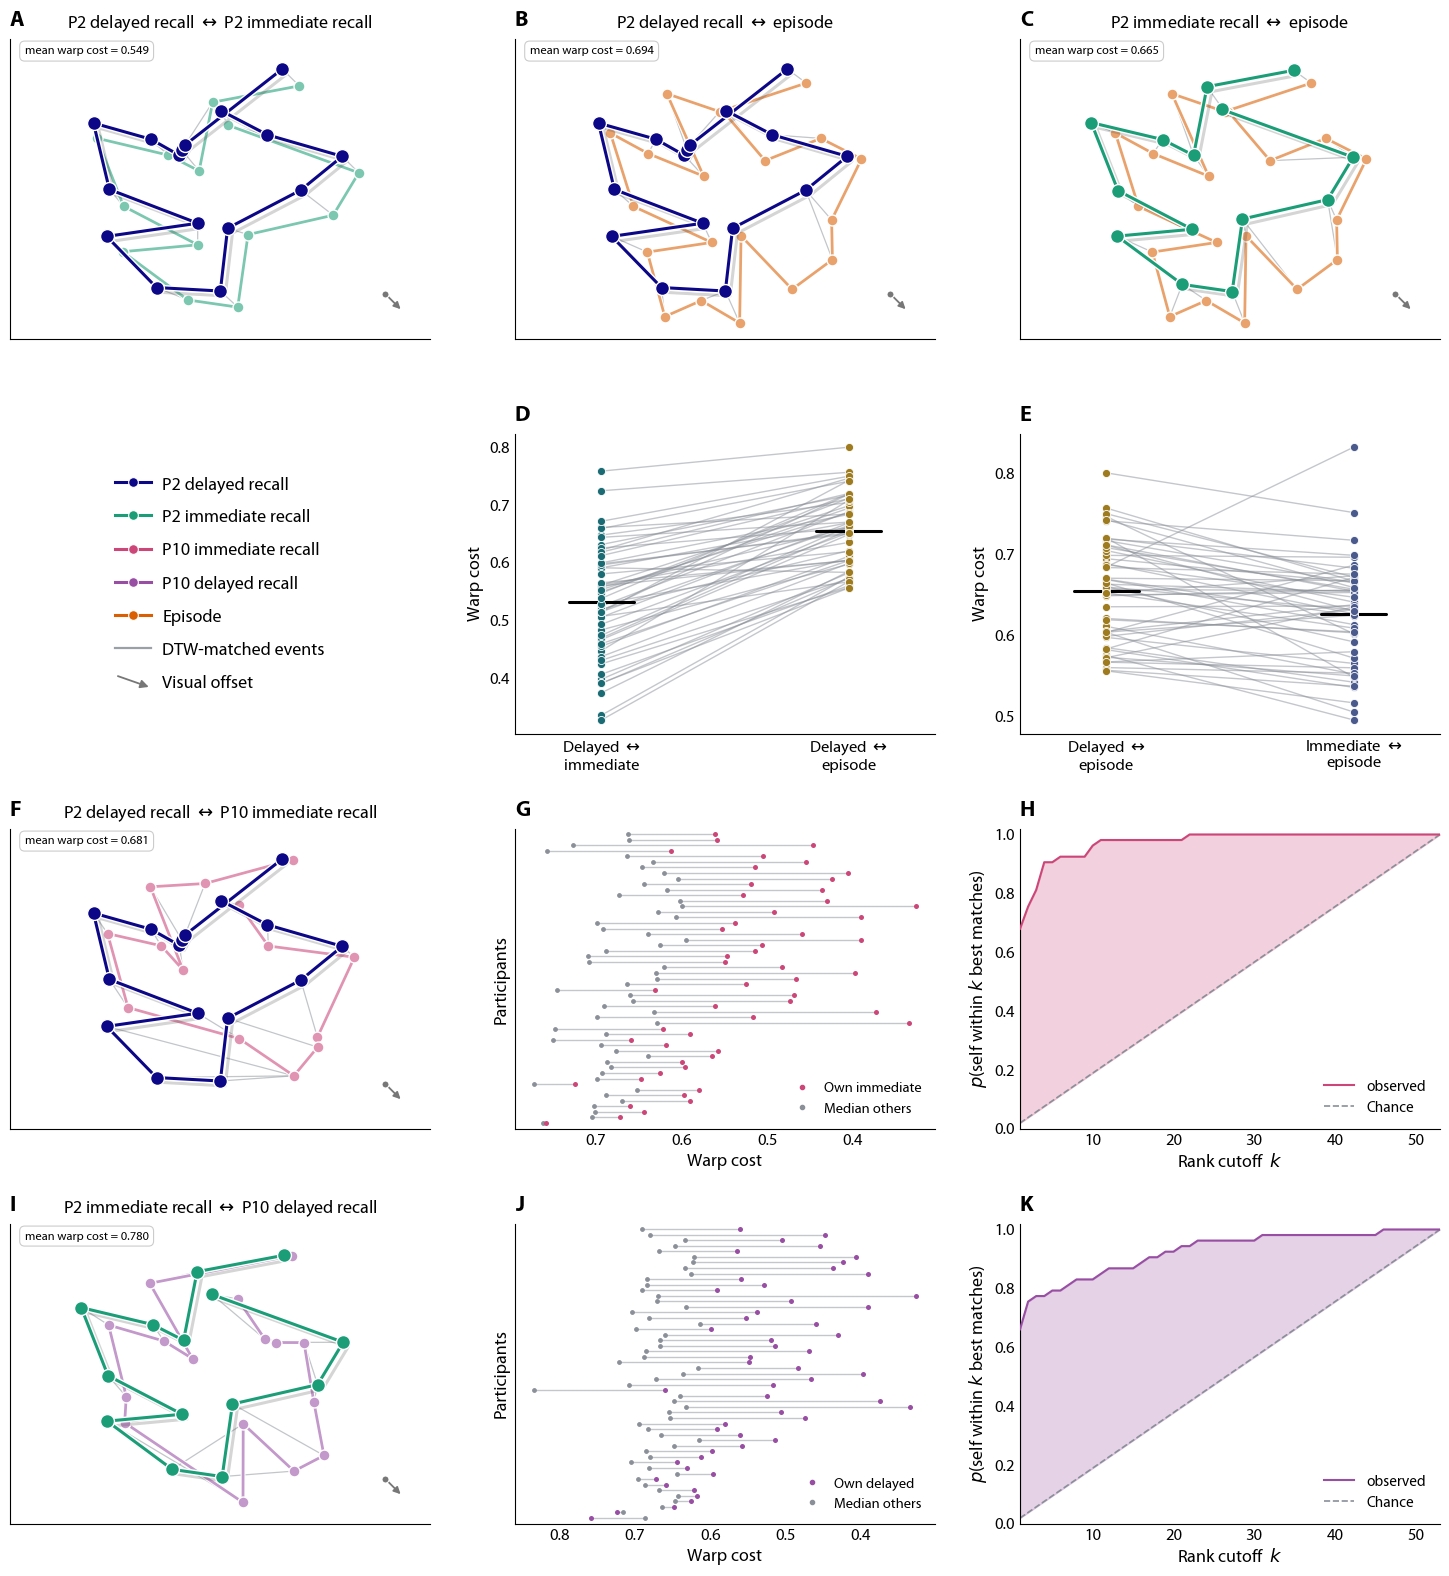

In [87]:
# ======================================================================
# DATA
# ======================================================================
MAIN_PID_N, OTHER_PID_N = 2, 10          # example participants: P2 ("self"), P10 ("other")
main_pid, other_pid = f'P{MAIN_PID_N}', f'P{OTHER_PID_N}'

with open('panel_data_updated.p', 'rb') as f:
    panels = pickle.load(f)

# 2-D UMAP trajectories (one point per recalled/​watched event)
traj_p2_del  = np.asarray(panels['del_path'])        # P2 delayed recall
traj_p2_imm  = np.asarray(panels['own_imm_path'])    # P2 immediate recall
traj_p10_imm = np.asarray(panels['other_imm_path'])  # P10 immediate recall
traj_p10_del = np.asarray(panels['p10_del_path'])    # P10 delayed recall
traj_episode = np.asarray(panels['episode_path'])    # the episode itself

# DTW alignments for the example panels, as lists of matched (front_idx, back_idx)
# event pairs, plus each pair's mean warp cost (shown in the panel's cost box).
warp_p2del_p2imm  = panels['own_imm_warp'];   cost_p2del_p2imm  = panels['own_imm_dist']
warp_p2del_ep     = panels['episode_warp'];   cost_p2del_ep     = panels['episode_dist']
warp_p2imm_ep     = panels['imm_ep_warp'];    cost_p2imm_ep     = panels['imm_ep_dist']
warp_p2del_p10imm = panels['other_imm_warp']; cost_p2del_p10imm = panels['other_imm_dist']
# Stored as (P10-delayed idx, P2-immediate idx); panel I draws P2-immediate in front,
# so swap each pair to (front_idx, back_idx).
warp_p10del_p2imm = [(back, front) for (front, back) in panels['p10del_p2imm_warp']]
cost_p10del_p2imm = panels['p10del_p2imm_dist']

# Per-participant DTW costs for the two episode analyses (slope panels D and E).
with open('self_vs_episode_data.p', 'rb') as f:
    sve = pickle.load(f)
costs_del_imm = np.asarray(sve['warp_dists_imm'], float)      # delayed  <-> own immediate
costs_del_ep  = np.asarray(sve['warp_dists_episode'], float)  # delayed  <-> episode
with open('del_imm_vs_episode_data.p', 'rb') as f:
    die = pickle.load(f)
costs_imm_ep  = np.asarray(die['warp_dists_imm_episode'], float)  # immediate <-> episode

# Full delayed x immediate cost matrix: cost_matrix[i, j] = DTW(delayed i, immediate j).
# The diagonal is each participant's own delayed-vs-immediate cost.
cost_matrix = np.load('warp_dists.npy')

# ======================================================================
# CONFIG
# ======================================================================
# ---- entity colors (trajectory paths + shared legend) ----------------
MAIN_DELAYED_COLOR    = "#0c0786"   # P2 delayed recall
MAIN_IMMEDIATE_COLOR  = "#1B9E77"   # P2 immediate recall
OTHER_IMMEDIATE_COLOR = "#cc4778"   # P10 immediate recall  (also forward-results accent: G, H)
OTHER_DELAYED_COLOR   = "#984EA3"   # P10 delayed recall    (also reverse-results accent: J, K)
EPISODE_COLOR         = "#D95F02"   # the episode
WARP_LINE_COLOR       = "#9AA0A6"   # DTW match lines inside trajectory panels
SURROGATE_COLOR       = "#8a8f98"   # neutral grey: median-others dots, connectors, chance line

# ---- slope dot colors (one per pairwise comparison; panels D & E) -----
# Each delayed/immediate/episode comparison gets its own color, so the shared
# delayed<->episode stack reads the same in both slope panels.
COMPARISON_COLOR_DEL_IMM = "#1a6b73"   # teal   delayed <-> immediate
COMPARISON_COLOR_DEL_EP  = "#9e7b1e"   # gold   delayed <-> episode
COMPARISON_COLOR_IMM_EP  = "#4a5a8c"   # slate  immediate <-> episode

# ---- connectors (per-participant lines in slope & dumbbell panels) ----
CONNECTOR_COLOR = SURROGATE_COLOR
CONNECTOR_ALPHA = 0.5
CONNECTOR_LW    = 1.0

# ---- panel letters ---------------------------------------------------
PANEL_LETTER_FONTSIZE = 16
PANEL_LETTER_DX = 0.0     # x-offset (axes fraction) from the top-left corner
PANEL_LETTER_DY = 0.03    # y-offset (axes fraction) above the top of the axes

# ---- trajectory panels (A, B, C, F, I) -------------------------------
EVENT_MARKERSIZE   = 100
EVENT_BORDER_WIDTH = 1
PATH_LINEWIDTH     = 2.2
PATH_CASING_WIDTH  = PATH_LINEWIDTH + 2
WARP_LINEWIDTH     = 0.9
WARP_LINE_ALPHA    = 0.6
DEPTH_OFFSET       = (5.0, -5.0)   # (dx, dy) shift of the receding "back" path
BACK_LIGHTEN       = 0.42          # 0 = full colour, 1 = white
BACK_LW_SCALE      = 0.9
BACK_MARKER_SCALE  = 0.62
BACK_CASING_EXTRA  = 1.5
SHADOW_OFFSET      = (3.5, -3.5)
SHADOW_COLOR       = "#404040"
SHADOW_ALPHA       = 0.22
SHOW_OFFSET_INDICATOR = True
OFFSET_COLOR       = "#777777"
OFFSET_ARROW_LW    = 1.3
OFFSET_DOT_SIZE    = 26
TRAJ_XLIM_PAD      = 5
TRAJ_YLIM_PAD      = 5
TRAJ_TITLE_FONTSIZE = 13
TRAJ_TITLE_PAD      = 8
COST_BOX_X, COST_BOX_Y = 0.035, 0.975   # "mean warp cost" box position (axes fraction)
COST_BOX_FONTSIZE  = 9

# ---- slope panels (D, E) ---------------------------------------------
SLOPE_X             = (0.0, 1.0)   # x positions of the (left, right) stacks
SLOPE_XPAD          = 0.35         # x-margin beyond the outer stacks
SLOPE_DOT_SIZE      = 34
SLOPE_DOT_EDGE_W    = 0.6
MEAN_TICK_COLOR     = "black"
MEAN_TICK_LW        = 2.2
MEAN_TICK_HALFWIDTH = 0.13         # in x-data units
SLOPE_E_YTICK_STEP  = 0.1          # y-tick spacing for panel E

# ---- dumbbell panels (G, J): own vs. median-of-others ----------------
DUMBBELL_MEDIAN_DOT_SIZE = 6
DUMBBELL_OWN_DOT_SIZE    = 13
DUMBBELL_OWN_EDGE_W      = 0
DUMBBELL_LEGEND_FONTSIZE = 10.5

# ---- top-k accuracy panels (H, K) ------------------------------------
ACC_LINE_WIDTH      = 1.5
ACC_FILL_ALPHA      = 0.25
CHANCE_LINE_WIDTH   = 1.2
ACC_LEGEND_FONTSIZE = 11

# ---- results panels: shared tick/label styling -----------------------
RESULTS_TICKLABEL_FONTSIZE = 12
RESULTS_AXISLABEL_FONTSIZE = 13

# ---- shared trajectory legend ----------------------------------------
LEGEND_FONTSIZE = 13

# ---- figure layout (inches) ------------------------------------------
N_COLS = 3
N_ROWS = 4
CELL_ASPECT = 1.4                  # width:height of the trajectory & quant panels
ROW_HEIGHT  = 3.0
COL_WIDTH   = CELL_ASPECT * ROW_HEIGHT
COL_GAP     = 0.85
ROW_GAP     = 0.95
MARGIN_L, MARGIN_R, MARGIN_T, MARGIN_B = 0.95, 0.45, 0.70, 0.55
QUANT_BOX_ASPECT = 1.0 / CELL_ASPECT   # height:width for the box-pinned quant panels

# ======================================================================
# COMPUTATIONS
# ======================================================================
_depth = np.asarray(DEPTH_OFFSET)

# Shared trajectory axis limits: include the shifted "back" paths so nothing clips,
# then widen the x-range so the equal-aspect panels fill the column aspect ratio.
_all_pts = np.vstack([traj_p2_del, traj_p2_imm, traj_p10_imm, traj_p10_del, traj_episode,
                      traj_p2_del + _depth, traj_p2_imm + _depth, traj_p10_imm + _depth,
                      traj_p10_del + _depth, traj_episode + _depth])
traj_xmin, traj_ymin = _all_pts.min(axis=0) - [TRAJ_XLIM_PAD, TRAJ_YLIM_PAD]
traj_xmax, traj_ymax = _all_pts.max(axis=0) + [TRAJ_XLIM_PAD, TRAJ_YLIM_PAD]
_xc = 0.5 * (traj_xmin + traj_xmax)
_xhalf = 0.5 * CELL_ASPECT * (traj_ymax - traj_ymin)
traj_xmin, traj_xmax = _xc - _xhalf, _xc + _xhalf

n_participants = cost_matrix.shape[0]
chance = np.arange(1, n_participants + 1) / n_participants   # top-k chance curve


def identification_stats(cost_mx):
    """For an n x n cost matrix (rows = query recalls, cols = target recalls, diagonal =
    own-vs-own), return (own_cost, sort_order, topk_accuracy):
      own_cost      -- each query's cost against its own target (the diagonal),
      sort_order    -- participant order, best-identified first (for the dumbbell rows),
      topk_accuracy -- P(own target is within the k nearest targets), for k = 1..n,
                       computed tie-aware.
    """
    n = cost_mx.shape[0]
    own_cost = np.diag(cost_mx).copy()
    others = [np.delete(cost_mx[i], i) for i in range(n)]
    pct_rank = np.array([((own_cost[i] > others[i]).sum()
                          + 0.5 * (own_cost[i] == others[i]).sum()) / (n - 1)
                         for i in range(n)])
    sort_order = np.argsort(pct_rank)                       # best-identified first
    n_below = np.array([(others[i] < own_cost[i]).sum() for i in range(n)])
    n_tied  = np.array([(others[i] == own_cost[i]).sum() for i in range(n)])
    topk_accuracy = np.array([np.mean(np.clip(k - n_below, 0, n_tied + 1) / (n_tied + 1))
                              for k in range(1, n + 1)])
    return own_cost, sort_order, topk_accuracy


# Forward: identify each delayed recall by its own immediate recall.
fwd_own, fwd_order, fwd_acc = identification_stats(cost_matrix)
# Reverse: identify each immediate recall by its own delayed recall.
rev_own, rev_order, rev_acc = identification_stats(cost_matrix.T)

# ======================================================================
# DRAWING HELPERS
# ======================================================================
def _blend_white(color, amount):
    """Blend a color toward white (lighten + desaturate) by amount in [0, 1]."""
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1.0 - rgb) * amount)


def draw_dtw_matches(ax, path_front, path_back, warp):
    """Thin grey lines joining each DTW-matched pair of events between two paths."""
    for front_idx, back_idx in warp:
        ax.plot([path_front[front_idx, 0], path_back[back_idx, 0]],
                [path_front[front_idx, 1], path_back[back_idx, 1]],
                color=WARP_LINE_COLOR, alpha=WARP_LINE_ALPHA, lw=WARP_LINEWIDTH,
                zorder=1, solid_capstyle="round")


def draw_event_path(ax, path, color, offset=(0.0, 0.0), back=False, shadow=False):
    """Draw one event path. back=True makes it recede (offset, lighter, smaller, lower);
    shadow=True casts a soft drop-shadow so the front path floats above."""
    pts = np.asarray(path) + np.asarray(offset)
    if back:
        color = _blend_white(color, BACK_LIGHTEN)
        lw = PATH_LINEWIDTH * BACK_LW_SCALE
        casing = lw + BACK_CASING_EXTRA
        markersize = EVENT_MARKERSIZE * BACK_MARKER_SCALE
        z_line, z_mark = 2.0, 2.6
    else:
        lw = PATH_LINEWIDTH
        casing = PATH_CASING_WIDTH
        markersize = EVENT_MARKERSIZE
        z_line, z_mark = 4.0, 6.0
    effects = [pe.Stroke(linewidth=casing, foreground="white"), pe.Normal()]
    if shadow:
        effects = [pe.SimpleLineShadow(offset=SHADOW_OFFSET, shadow_color=SHADOW_COLOR,
                                       alpha=SHADOW_ALPHA, rho=1.0)] + effects
    ax.plot(pts[:, 0], pts[:, 1], "-", color=color, lw=lw, zorder=z_line,
            solid_capstyle="round", solid_joinstyle="round", path_effects=effects)
    ax.scatter(pts[:, 0], pts[:, 1], s=markersize, color=color, zorder=z_mark,
               edgecolor="white", linewidth=EVENT_BORDER_WIDTH)


def draw_offset_indicator(ax):
    """Small arrow (with a dot at its tail) showing the fixed 'depth' offset applied to
    the receding back path, placed in the panel's lower-right corner."""
    span = max(traj_xmax - traj_xmin, traj_ymax - traj_ymin)
    margin = 0.07 * span
    head = np.array([traj_xmax - margin, traj_ymin + margin])
    tail = head - _depth
    ax.annotate("", xy=tuple(head), xytext=tuple(tail),
                arrowprops=dict(arrowstyle="-|>", color=OFFSET_COLOR, lw=OFFSET_ARROW_LW,
                                shrinkA=0, shrinkB=0), zorder=8)
    ax.scatter(*tail, s=OFFSET_DOT_SIZE, color=OFFSET_COLOR, edgecolor="white",
               linewidth=0.8, zorder=8)


def add_panel_letter(ax, letter, dx=PANEL_LETTER_DX, dy=PANEL_LETTER_DY):
    """Bold panel letter at the top-left of ax, offset by (dx, dy) in axes fraction so
    all letters can be nudged together while staying aligned."""
    ax.text(dx, 1.0 + dy, letter, transform=ax.transAxes, fontweight='bold',
            fontsize=PANEL_LETTER_FONTSIZE, ha='left', va='bottom')


class _HandlerArrow(HandlerPatch):
    """Legend handler that renders the FancyArrowPatch proxy as a small diagonal arrow
    (down-right), matching the in-panel visual-offset indicators."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height,
                       fontsize, trans):
        arrow = FancyArrowPatch((0, height), (width, 0), arrowstyle='-|>', mutation_scale=12,
                                color=OFFSET_COLOR, lw=OFFSET_ARROW_LW)
        arrow.set_transform(trans)
        return [arrow]

# ======================================================================
# PANEL DRAWERS
# ======================================================================
def draw_traj_panel(ax, front_path, front_color, back_path, back_color, warp, title, mean_cost):
    """A trajectory-pair example: front path over a receding, lightened back path, with
    DTW match lines, a depth-offset indicator, a centered title, and a mean-cost box."""
    draw_dtw_matches(ax, front_path, back_path + _depth, warp)
    draw_event_path(ax, back_path, back_color, offset=DEPTH_OFFSET, back=True)
    draw_event_path(ax, front_path, front_color, shadow=True)
    if SHOW_OFFSET_INDICATOR:
        draw_offset_indicator(ax)
    ax.set_xlim(traj_xmin, traj_xmax)
    ax.set_ylim(traj_ymin, traj_ymax)
    ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(title, loc='center', fontsize=TRAJ_TITLE_FONTSIZE, pad=TRAJ_TITLE_PAD)
    ax.text(COST_BOX_X, COST_BOX_Y, f'mean warp cost = {mean_cost:.3f}',
            transform=ax.transAxes, ha="left", va="top", fontsize=COST_BOX_FONTSIZE,
            bbox={'boxstyle': 'round,pad=0.4', 'fc': 'white', 'ec': '#cccccc', 'lw': 0.8})


def draw_slope_panel(ax, left_costs, right_costs, left_color, right_color, xticklabels):
    """Paired slope of two per-participant cost vectors: connectors, per-stack mean ticks,
    and colored dots for the left and right conditions."""
    x_l, x_r = SLOPE_X
    for a, b in zip(left_costs, right_costs):
        ax.plot([x_l, x_r], [a, b], color=CONNECTOR_COLOR, alpha=CONNECTOR_ALPHA,
                lw=CONNECTOR_LW, zorder=1, solid_capstyle='round')
    for x, costs in ((x_l, left_costs), (x_r, right_costs)):
        mean = costs.mean()
        ax.plot([x - MEAN_TICK_HALFWIDTH, x + MEAN_TICK_HALFWIDTH], [mean, mean],
                color=MEAN_TICK_COLOR, lw=MEAN_TICK_LW, solid_capstyle='round', zorder=3)
    ax.scatter(np.full_like(left_costs, x_l), left_costs, s=SLOPE_DOT_SIZE, c=left_color,
               edgecolors='white', linewidths=SLOPE_DOT_EDGE_W, zorder=5)
    ax.scatter(np.full_like(right_costs, x_r), right_costs, s=SLOPE_DOT_SIZE, c=right_color,
               edgecolors='white', linewidths=SLOPE_DOT_EDGE_W, zorder=5)
    ax.set_xlim(x_l - SLOPE_XPAD, x_r + SLOPE_XPAD)
    ax.set_xticks([x_l, x_r])
    ax.set_xticklabels(xticklabels)
    ax.set_ylabel('Warp cost')
    ax.spines[['top', 'right']].set_visible(False)


def draw_dumbbell_panel(ax, cost_mx, own_cost, sort_order, own_label, accent_color):
    """One row per participant (best-identified at top): the participant's own cost vs.
    the median of their costs against everyone else's recalls."""
    for row, i in enumerate(sort_order):
        y = n_participants - 1 - row
        median_others = np.median(np.delete(cost_mx[i], i))
        ax.plot([median_others, own_cost[i]], [y, y], color=CONNECTOR_COLOR,
                lw=CONNECTOR_LW, alpha=CONNECTOR_ALPHA, zorder=1)
        ax.scatter(median_others, y, s=DUMBBELL_MEDIAN_DOT_SIZE, c=SURROGATE_COLOR, zorder=2)
        ax.scatter(own_cost[i], y, s=DUMBBELL_OWN_DOT_SIZE, c=accent_color,
                   edgecolors='w', linewidths=DUMBBELL_OWN_EDGE_W, zorder=3)
    ax.set_xlabel('Warp cost')
    ax.set_ylabel('Participants')
    ax.set_ylim(-1, n_participants)
    ax.set_yticks([])
    ax.invert_xaxis()
    handles = [Line2D([], [], marker='o', color=accent_color, linestyle='None',
                      markersize=3, label=own_label),
               Line2D([], [], marker='o', color=SURROGATE_COLOR, linestyle='None',
                      markersize=3, label='Median others')]
    ax.legend(handles=handles, loc='lower right', bbox_to_anchor=(1, 0),
              fontsize=DUMBBELL_LEGEND_FONTSIZE, frameon=False,
              handletextpad=0.5, labelspacing=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_box_aspect(QUANT_BOX_ASPECT)


def draw_accuracy_panel(ax, topk_accuracy, ylabel, accent_color):
    """Top-k identification accuracy vs. rank cutoff k, shaded against the chance curve."""
    ks = range(1, n_participants + 1)
    ax.fill_between(ks, chance, topk_accuracy, color=accent_color, alpha=ACC_FILL_ALPHA, zorder=1)
    ax.plot(ks, topk_accuracy, color=accent_color, lw=ACC_LINE_WIDTH, zorder=3, label='observed')
    ax.plot(ks, chance, color=SURROGATE_COLOR, lw=CHANCE_LINE_WIDTH, ls='--', zorder=2, label='Chance')
    ax.set_xlabel('Rank cutoff  $k$')
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, n_participants)
    ax.set_ylim(0, 1.02)
    ax.legend(loc='lower right', fontsize=ACC_LEGEND_FONTSIZE, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_box_aspect(QUANT_BOX_ASPECT)

# ======================================================================
# FIGURE
# ======================================================================
plot_w = N_COLS * COL_WIDTH + (N_COLS - 1) * COL_GAP
plot_h = N_ROWS * ROW_HEIGHT + (N_ROWS - 1) * ROW_GAP
fig_w = MARGIN_L + plot_w + MARGIN_R
fig_h = MARGIN_B + plot_h + MARGIN_T
fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(N_ROWS, N_COLS,
                      left=MARGIN_L / fig_w, right=1 - MARGIN_R / fig_w,
                      bottom=MARGIN_B / fig_h, top=1 - MARGIN_T / fig_h,
                      wspace=COL_GAP / COL_WIDTH, hspace=ROW_GAP / ROW_HEIGHT)

# Trajectory examples share one coordinate frame; the results panels are independent.
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1], sharex=axA, sharey=axA)
axC = fig.add_subplot(gs[0, 2], sharex=axA, sharey=axA)
ax_legend = fig.add_subplot(gs[1, 0]); ax_legend.axis('off')
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[1, 2])
axF = fig.add_subplot(gs[2, 0], sharex=axA, sharey=axA)
axG = fig.add_subplot(gs[2, 1])
axH = fig.add_subplot(gs[2, 2])
axI = fig.add_subplot(gs[3, 0], sharex=axA, sharey=axA)
axJ = fig.add_subplot(gs[3, 1])
axK = fig.add_subplot(gs[3, 2])

# ---- row 1: pairwise trajectory examples -----------------------------
draw_traj_panel(axA, traj_p2_del, MAIN_DELAYED_COLOR, traj_p2_imm, MAIN_IMMEDIATE_COLOR,
                warp_p2del_p2imm,
                f'{main_pid} delayed recall $\\leftrightarrow$ {main_pid} immediate recall',
                cost_p2del_p2imm)
draw_traj_panel(axB, traj_p2_del, MAIN_DELAYED_COLOR, traj_episode, EPISODE_COLOR,
                warp_p2del_ep,
                f'{main_pid} delayed recall $\\leftrightarrow$ episode', cost_p2del_ep)
draw_traj_panel(axC, traj_p2_imm, MAIN_IMMEDIATE_COLOR, traj_episode, EPISODE_COLOR,
                warp_p2imm_ep,
                f'{main_pid} immediate recall $\\leftrightarrow$ episode', cost_p2imm_ep)

# ---- row 2 left: shared legend ---------------------------------------
legend_entries = [(MAIN_DELAYED_COLOR, f'{main_pid} delayed recall'),
                  (MAIN_IMMEDIATE_COLOR, f'{main_pid} immediate recall'),
                  (OTHER_IMMEDIATE_COLOR, f'{other_pid} immediate recall'),
                  (OTHER_DELAYED_COLOR, f'{other_pid} delayed recall'),
                  (EPISODE_COLOR, 'Episode')]
legend_handles = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c,
                         markeredgecolor='white', markeredgewidth=0.8, markersize=7,
                         lw=2.2, label=lab) for c, lab in legend_entries]
legend_handles.append(Line2D([0], [0], color=WARP_LINE_COLOR, lw=1.6, label='DTW-matched events'))
legend_handles.append(FancyArrowPatch((0, 0), (1, 0), arrowstyle='-|>', mutation_scale=12,
                                      color=OFFSET_COLOR, lw=OFFSET_ARROW_LW, label='Visual offset'))
ax_legend.legend(handles=legend_handles, loc='center', ncol=1, frameon=False,
                 fontsize=LEGEND_FONTSIZE, handletextpad=0.6, labelspacing=0.9,
                 handler_map={FancyArrowPatch: _HandlerArrow()})

# ---- row 2 middle/right: the two episode-analysis slopes --------------
# D (analysis 1): P2 delayed<->immediate  vs  P2 delayed<->episode      (reads A -> B)
draw_slope_panel(axD, costs_del_imm, costs_del_ep, COMPARISON_COLOR_DEL_IMM, COMPARISON_COLOR_DEL_EP,
                 ['Delayed $\\leftrightarrow$\nimmediate', 'Delayed $\\leftrightarrow$\nepisode'])
# E (analysis 2): P2 delayed<->episode  vs  P2 immediate<->episode      (reads B -> C)
draw_slope_panel(axE, costs_del_ep, costs_imm_ep, COMPARISON_COLOR_DEL_EP, COMPARISON_COLOR_IMM_EP,
                 ['Delayed $\\leftrightarrow$\nepisode', 'Immediate $\\leftrightarrow$\nepisode'])

# ---- row 3: forward identification (example | dumbbell | accuracy) ---
draw_traj_panel(axF, traj_p2_del, MAIN_DELAYED_COLOR, traj_p10_imm, OTHER_IMMEDIATE_COLOR,
                warp_p2del_p10imm,
                f'{main_pid} delayed recall $\\leftrightarrow$ {other_pid} immediate recall',
                cost_p2del_p10imm)
draw_dumbbell_panel(axG, cost_matrix, fwd_own, fwd_order, 'Own immediate', OTHER_IMMEDIATE_COLOR)
draw_accuracy_panel(axH, fwd_acc, '$p$(self within $k$ best matches)', OTHER_IMMEDIATE_COLOR)

# ---- row 4: reverse identification (example | dumbbell | accuracy) ---
draw_traj_panel(axI, traj_p2_imm, MAIN_IMMEDIATE_COLOR, traj_p10_del, OTHER_DELAYED_COLOR,
                warp_p10del_p2imm,
                f'{main_pid} immediate recall $\\leftrightarrow$ {other_pid} delayed recall',
                cost_p10del_p2imm)
draw_dumbbell_panel(axJ, cost_matrix.T, rev_own, rev_order, 'Own delayed', OTHER_DELAYED_COLOR)
draw_accuracy_panel(axK, rev_acc, '$p$(self within $k$ best matches)', OTHER_DELAYED_COLOR)

# ---- results panels: tick/label sizes & spacing, no tick marks -------
for ax in (axD, axE, axG, axH, axJ, axK):
    ax.tick_params(axis='both', length=0, labelsize=RESULTS_TICKLABEL_FONTSIZE)
    ax.xaxis.label.set_fontsize(RESULTS_AXISLABEL_FONTSIZE)
    ax.yaxis.label.set_fontsize(RESULTS_AXISLABEL_FONTSIZE)
axE.yaxis.set_major_locator(MultipleLocator(SLOPE_E_YTICK_STEP))

# ---- panel letters ---------------------------------------------------
for ax, letter in ((axA, 'A'), (axB, 'B'), (axC, 'C'), (axD, 'D'), (axE, 'E'), (axF, 'F'),
                   (axG, 'G'), (axH, 'H'), (axI, 'I'), (axJ, 'J'), (axK, 'K')):
    add_panel_letter(ax, letter)

    
# plt.savefig(FIG_DIR / 'dtw-figure.pdf', bbox_inches='tight')
plt.show()